# Notebook 02: Crossing Mechanics

## Gamete Formation & Self-Incompatibility

### Gamete formation
Each tetraploid parent produces **diploid gametes** by contributing 2 of its 4 alleles:
- `C(4, 2) = 6` possible gamete types per parent
- Under random segregation, each gamete type has probability `1/6`

### Self-Incompatibility (SI)
The S-locus controls **self-incompatibility**: pollen is rejected if it shares S-alleles with the maternal plant.
- A pollen gamete `(Sa, Sb)` is **incompatible** with maternal parent if `Sa` or `Sb` is present in the maternal genotype
- Only **compatible** pollen gametes can fertilize — offspring probabilities are computed from compatible combinations only
- If no pollen gametes are compatible, the cross is fully incompatible (no offspring)

### Offspring genotype
Each offspring receives:
- 2 alleles from the maternal gamete
- 2 alleles from a compatible paternal gamete
- Result: a 4-allele genotype stored in canonical (sorted) form

In [1]:
import itertools
from collections import Counter, defaultdict
from math import comb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ---------------------------------------------------------------------------
# Utility functions from Notebook 01
# ---------------------------------------------------------------------------

def canonical(alleles):
    """Return the canonical (sorted tuple) form of a genotype.

    Sorting ensures genotypes like (5,1,23,47) and (1,5,23,47) are stored
    identically, since allele order has no biological meaning.
    """
    return tuple(sorted(alleles))


def enumerate_genotypes(allele_pool, ploidy=4):
    """Enumerate all unique multiset genotypes for a given allele pool and ploidy.

    Uses combinations-with-replacement to generate all ways to choose `ploidy`
    alleles (with repeats allowed) from the pool.
    """
    return list(itertools.combinations_with_replacement(sorted(allele_pool), ploidy))


def allele_frequencies(population, allele_pool=None):
    """Compute allele frequencies across a population.

    Counts all allele copies (4 per tetraploid individual) and normalizes
    to proportions summing to 1.0.
    """
    counts = Counter()
    total = 0
    for genotype in population:
        for allele in genotype:
            counts[allele] += 1
            total += 1
    freqs = {a: counts[a] / total for a in counts}
    if allele_pool is not None:
        for a in allele_pool:
            if a not in freqs:
                freqs[a] = 0.0
    return dict(sorted(freqs.items()))


print("Utilities loaded.")

Utilities loaded.


In [2]:
# ---------------------------------------------------------------------------
# Crossing functions
# ---------------------------------------------------------------------------

def form_gametes(genotype):
    """Return all possible diploid gametes from a tetraploid genotype.

    In a tetraploid, gamete formation (meiosis) produces diploid gametes by
    selecting 2 of the 4 allele copies. Under random segregation, all C(4,2)=6
    combinations are equally likely. If the genotype has duplicate alleles
    (e.g., (1,1,2,3)), some gamete types will appear multiple times in the list,
    naturally reflecting their higher probability.

    Parameters
    ----------
    genotype : tuple[int, ...]
        A tetraploid genotype (4 alleles).

    Returns
    -------
    list[tuple[int, int]]
        All C(4,2)=6 gamete types (with duplicates if alleles repeat).
    """
    return list(itertools.combinations(genotype, 2))


def is_compatible(maternal_genotype, pollen_gamete):
    """Check if a pollen gamete is compatible with a maternal plant under SI.

    Under the strict SI model, a pollen grain is rejected if ANY of its
    S-alleles match the maternal plant's S-alleles. This prevents
    self-fertilization and mating between closely related individuals.
    The more alleles two plants share, the fewer compatible pollen gametes
    can succeed — this is the mechanistic basis for NFDS.

    Parameters
    ----------
    maternal_genotype : tuple[int, ...]
        The maternal plant's genotype.
    pollen_gamete : tuple[int, int]
        A diploid pollen gamete.

    Returns
    -------
    bool
        True if compatible (no shared alleles), False otherwise.
    """
    maternal_alleles = set(maternal_genotype)
    return not any(a in maternal_alleles for a in pollen_gamete)


def cross(parent_a, parent_b):
    """Compute offspring genotype distribution from crossing parent_a (maternal) x parent_b (pollen).

    The crossing process:
    1. Generate all 6 maternal gametes (2-allele combinations from parent_a)
    2. Generate all 6 paternal gametes (2-allele combinations from parent_b)
    3. Filter paternal gametes by SI — reject any sharing alleles with parent_a
    4. Combine each maternal gamete with each compatible paternal gamete
    5. Each combination produces a 4-allele offspring genotype (2 + 2)
    6. Normalize to probabilities (all maternal gametes equally likely,
       all compatible paternal gametes equally likely)

    Parameters
    ----------
    parent_a : tuple[int, ...]
        Maternal parent genotype.
    parent_b : tuple[int, ...]
        Pollen donor genotype.

    Returns
    -------
    dict[tuple, float]
        Mapping from offspring genotype (canonical) to probability.
        Empty dict if the cross is fully incompatible.
    """
    maternal_gametes = form_gametes(parent_a)
    paternal_gametes = form_gametes(parent_b)

    # SI filter: only pollen gametes with NO shared alleles can fertilize
    compatible_paternal = [g for g in paternal_gametes if is_compatible(parent_a, g)]

    if not compatible_paternal:
        return {}  # Fully incompatible — no pollen can get through

    # Every (maternal, compatible paternal) pair is equally likely.
    # Offspring genotype = maternal gamete (2 alleles) + paternal gamete (2 alleles)
    offspring_counts = Counter()
    total_combinations = len(maternal_gametes) * len(compatible_paternal)

    for mg in maternal_gametes:
        for pg in compatible_paternal:
            # Combine gametes and sort to canonical form
            offspring_genotype = canonical(mg + pg)
            offspring_counts[offspring_genotype] += 1

    # Convert counts to probabilities
    return {g: count / total_combinations for g, count in sorted(offspring_counts.items())}


def crossing_compatibility(parent_a, parent_b):
    """Compute the fraction of compatible pollen gametes for a directed cross.

    This is a measure of how reproductively compatible two plants are:
    1.0 = all pollen accepted (no shared alleles), 0.0 = fully incompatible.
    """
    paternal_gametes = form_gametes(parent_b)
    compatible = sum(1 for g in paternal_gametes if is_compatible(parent_a, g))
    return compatible / len(paternal_gametes)


print("Crossing functions defined: form_gametes, is_compatible, cross, crossing_compatibility")

Crossing functions defined: form_gametes, is_compatible, cross, crossing_compatibility


## Worked Example: Small Cross

Cross `(1, 2, 3, 4)` (maternal) x `(5, 6, 7, 8)` (pollen donor).

Since the parents share **no alleles**, all pollen gametes are compatible — this is the maximum-compatibility case.

In [3]:
# Fully compatible cross: parents share NO S-alleles.
# Since SI rejects pollen carrying maternal alleles, zero overlap means
# all 6 pollen gametes are accepted — 100% compatibility.
# This is the ideal case for maximizing offspring diversity.
parent_a = (1, 2, 3, 4)
parent_b = (5, 6, 7, 8)

print(f"Maternal parent: {parent_a}")
print(f"Pollen donor:    {parent_b}")
print()

print("Maternal gametes:", form_gametes(parent_a))
print("Paternal gametes:", form_gametes(parent_b))
print()

# Verify: all paternal gametes should pass the SI filter
for g in form_gametes(parent_b):
    print(f"  Pollen {g} compatible: {is_compatible(parent_a, g)}")

print(f"\nCompatibility: {crossing_compatibility(parent_a, parent_b):.2%}")

# With 6 maternal * 6 paternal = 36 combinations, all producing unique
# offspring genotypes (since all 8 alleles are distinct)
offspring = cross(parent_a, parent_b)
print(f"\nOffspring genotypes ({len(offspring)} unique):")

df = pd.DataFrame([
    {"Genotype": str(g), "Probability": p}
    for g, p in offspring.items()
]).sort_values("Probability", ascending=False).reset_index(drop=True)

print(df.to_string(index=False))
print(f"\nProbabilities sum to: {sum(offspring.values()):.4f}")

Maternal parent: (1, 2, 3, 4)
Pollen donor:    (5, 6, 7, 8)

Maternal gametes: [(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]
Paternal gametes: [(5, 6), (5, 7), (5, 8), (6, 7), (6, 8), (7, 8)]

  Pollen (5, 6) compatible: True
  Pollen (5, 7) compatible: True
  Pollen (5, 8) compatible: True
  Pollen (6, 7) compatible: True
  Pollen (6, 8) compatible: True
  Pollen (7, 8) compatible: True

Compatibility: 100.00%

Offspring genotypes (36 unique):
    Genotype  Probability
(1, 2, 5, 6)     0.027778
(1, 2, 5, 7)     0.027778
(2, 3, 5, 8)     0.027778
(2, 3, 6, 7)     0.027778
(2, 3, 6, 8)     0.027778
(2, 3, 7, 8)     0.027778
(2, 4, 5, 6)     0.027778
(2, 4, 5, 7)     0.027778
(2, 4, 5, 8)     0.027778
(2, 4, 6, 7)     0.027778
(2, 4, 6, 8)     0.027778
(2, 4, 7, 8)     0.027778
(3, 4, 5, 6)     0.027778
(3, 4, 5, 7)     0.027778
(3, 4, 5, 8)     0.027778
(3, 4, 6, 7)     0.027778
(3, 4, 6, 8)     0.027778
(2, 3, 5, 7)     0.027778
(2, 3, 5, 6)     0.027778
(1, 4, 7, 8)     0.027778
(1

### Partially Incompatible Cross

Now cross two parents that **share some alleles**: `(1, 2, 3, 4)` x `(3, 4, 5, 6)`. Some pollen gametes will be rejected by SI.

In [4]:
# Partially incompatible cross: parents share alleles S3 and S4.
# Any pollen gamete containing S3 or S4 will be rejected by SI because
# those alleles are present in the maternal plant. For example:
#   - Pollen (3,4) -> REJECTED (both alleles match maternal)
#   - Pollen (3,5) -> REJECTED (S3 matches maternal)
#   - Pollen (5,6) -> COMPATIBLE (neither allele in maternal)
# Only gametes composed entirely of non-shared alleles (S5, S6) can succeed.
parent_a2 = (1, 2, 3, 4)
parent_b2 = (3, 4, 5, 6)

print(f"Maternal parent: {parent_a2}")
print(f"Pollen donor:    {parent_b2}")
print(f"Shared alleles:  {set(parent_a2) & set(parent_b2)}")
print()

print("Paternal gamete compatibility:")
for g in form_gametes(parent_b2):
    compat = is_compatible(parent_a2, g)
    print(f"  {g} -> {'COMPATIBLE' if compat else 'REJECTED'}")

print(f"\nCompatibility: {crossing_compatibility(parent_a2, parent_b2):.2%}")

offspring2 = cross(parent_a2, parent_b2)
if offspring2:
    print(f"\nOffspring genotypes ({len(offspring2)} unique):")
    df2 = pd.DataFrame([
        {"Genotype": str(g), "Probability": p}
        for g, p in offspring2.items()
    ]).sort_values("Probability", ascending=False).reset_index(drop=True)
    print(df2.to_string(index=False))
    print(f"Probabilities sum to: {sum(offspring2.values()):.4f}")
else:
    print("\nCross is FULLY INCOMPATIBLE — no offspring.")

Maternal parent: (1, 2, 3, 4)
Pollen donor:    (3, 4, 5, 6)
Shared alleles:  {3, 4}

Paternal gamete compatibility:
  (3, 4) -> REJECTED
  (3, 5) -> REJECTED
  (3, 6) -> REJECTED
  (4, 5) -> REJECTED
  (4, 6) -> REJECTED
  (5, 6) -> COMPATIBLE

Compatibility: 16.67%

Offspring genotypes (6 unique):
    Genotype  Probability
(1, 2, 5, 6)     0.166667
(1, 3, 5, 6)     0.166667
(1, 4, 5, 6)     0.166667
(2, 3, 5, 6)     0.166667
(2, 4, 5, 6)     0.166667
(3, 4, 5, 6)     0.166667
Probabilities sum to: 1.0000


## Crossing Matrix: All Pairwise Crosses

For a set of genotypes, we build a **crossing matrix** that stores:
1. Whether each directed pair is compatible
2. The offspring distribution for compatible crosses

We start with a small set of genotypes to keep the output readable.

In [5]:
def build_crossing_matrix(genotypes):
    """Build a crossing matrix for all ordered pairs of genotypes.

    Computes SI compatibility and offspring distributions for every directed
    cross (A x B is different from B x A because SI is evaluated against
    the maternal parent's alleles).

    Parameters
    ----------
    genotypes : list[tuple]
        List of genotypes in canonical form.

    Returns
    -------
    compatibility : dict[(tuple, tuple), float]
        Compatibility fraction for each directed cross.
    outcomes : dict[(tuple, tuple), dict[tuple, float]]
        Offspring distributions for each directed cross.
    """
    compatibility = {}
    outcomes = {}

    for i, ga in enumerate(genotypes):
        for j, gb in enumerate(genotypes):
            if i == j:
                # Self-cross: always fully incompatible under SI.
                # By definition, all pollen gametes from a plant share alleles
                # with itself, so every gamete is rejected.
                compatibility[(ga, gb)] = 0.0
                outcomes[(ga, gb)] = {}
            else:
                compat = crossing_compatibility(ga, gb)
                compatibility[(ga, gb)] = compat
                outcomes[(ga, gb)] = cross(ga, gb)

    return compatibility, outcomes


# Small genotype set for demonstration — 5 genotypes with varying overlap
demo_genotypes = [
    (1, 2, 3, 4),
    (1, 2, 5, 6),
    (3, 4, 5, 6),
    (5, 6, 7, 8),
    (1, 3, 5, 7),
]

compat_matrix, outcome_matrix = build_crossing_matrix(demo_genotypes)

# The matrix is 5x5 = 25 directed pairs, with 5 self-crosses always at 0
print(f"Built crossing matrix for {len(demo_genotypes)} genotypes")
print(f"Total directed pairs: {len(demo_genotypes)**2}")
compatible_count = sum(1 for v in compat_matrix.values() if v > 0)
print(f"Compatible pairs: {compatible_count}")

Built crossing matrix for 5 genotypes
Total directed pairs: 25
Compatible pairs: 20


## Compatibility Heatmap

Visualize pairwise compatibility as a heatmap. Each cell shows the fraction of pollen gametes that are compatible (0 = fully incompatible, 1 = fully compatible).

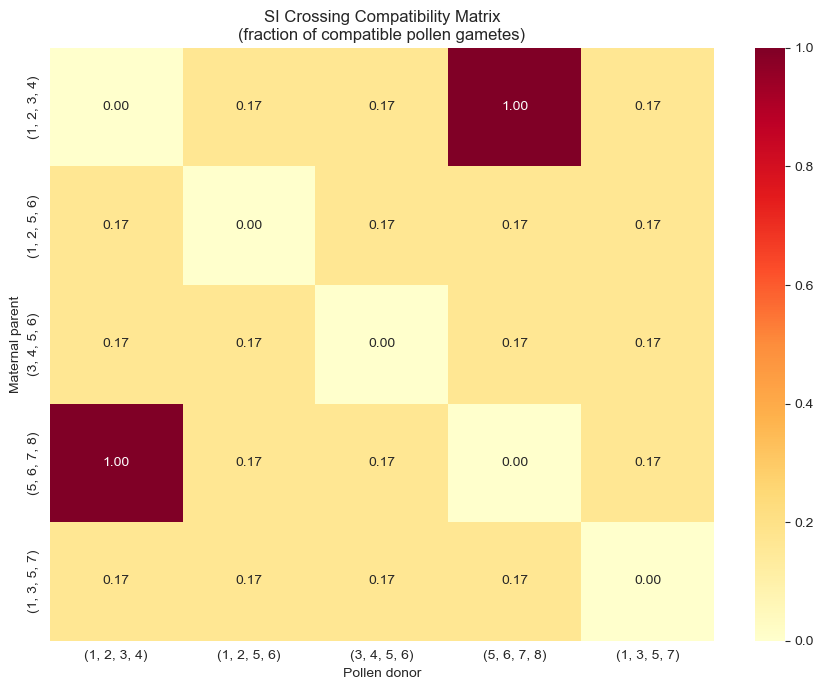

In [6]:
# Heatmap of SI compatibility between all genotype pairs.
# Color scale: 0.0 (dark/cool) = fully incompatible, 1.0 (bright/warm) = fully compatible.
# The diagonal is always 0 (self-incompatibility).
# Off-diagonal values reflect the fraction of pollen gametes that pass SI —
# higher values mean the parents share fewer alleles and are more reproductively compatible.
n = len(demo_genotypes)
compat_array = np.zeros((n, n))

for i, ga in enumerate(demo_genotypes):
    for j, gb in enumerate(demo_genotypes):
        compat_array[i, j] = compat_matrix[(ga, gb)]

labels = [str(g) for g in demo_genotypes]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    compat_array,
    annot=True,
    fmt=".2f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    ax=ax,
)
ax.set_xlabel("Pollen donor")
ax.set_ylabel("Maternal parent")
ax.set_title("SI Crossing Compatibility Matrix\n(fraction of compatible pollen gametes)")
plt.tight_layout()
plt.show()

## Full Crossing Outcome Table

For each compatible cross, display the offspring genotype distribution.

In [7]:
# Full crossing outcome table: for each compatible cross, list every possible
# offspring genotype and its probability. This is the raw data a breeder
# would use to predict outcomes of specific crosses.
rows = []
for (ga, gb), outcomes in outcome_matrix.items():
    if outcomes:  # Only show compatible crosses (skip incompatible pairs)
        for offspring_g, prob in outcomes.items():
            rows.append({
                "Maternal": str(ga),
                "Pollen": str(gb),
                "Offspring": str(offspring_g),
                "Probability": prob,
            })

df_outcomes = pd.DataFrame(rows)
print(f"Total offspring entries: {len(df_outcomes)}")
print()

# Summary view: how many distinct offspring genotypes does each cross produce?
# More unique offspring = higher genetic diversity from that cross.
# prob_sum should always be 1.0 (sanity check).
summary = df_outcomes.groupby(["Maternal", "Pollen"]).agg(
    n_offspring=("Offspring", "nunique"),
    prob_sum=("Probability", "sum"),
).reset_index()

print("Cross summary (unique offspring count per compatible cross):")
print(summary.to_string(index=False))

Total offspring entries: 180

Cross summary (unique offspring count per compatible cross):
    Maternal       Pollen  n_offspring  prob_sum
(1, 2, 3, 4) (1, 2, 5, 6)            6       1.0
(1, 2, 3, 4) (1, 3, 5, 7)            6       1.0
(1, 2, 3, 4) (3, 4, 5, 6)            6       1.0
(1, 2, 3, 4) (5, 6, 7, 8)           36       1.0
(1, 2, 5, 6) (1, 2, 3, 4)            6       1.0
(1, 2, 5, 6) (1, 3, 5, 7)            6       1.0
(1, 2, 5, 6) (3, 4, 5, 6)            6       1.0
(1, 2, 5, 6) (5, 6, 7, 8)            6       1.0
(1, 3, 5, 7) (1, 2, 3, 4)            6       1.0
(1, 3, 5, 7) (1, 2, 5, 6)            6       1.0
(1, 3, 5, 7) (3, 4, 5, 6)            6       1.0
(1, 3, 5, 7) (5, 6, 7, 8)            6       1.0
(3, 4, 5, 6) (1, 2, 3, 4)            6       1.0
(3, 4, 5, 6) (1, 2, 5, 6)            6       1.0
(3, 4, 5, 6) (1, 3, 5, 7)            6       1.0
(3, 4, 5, 6) (5, 6, 7, 8)            6       1.0
(5, 6, 7, 8) (1, 2, 3, 4)           36       1.0
(5, 6, 7, 8) (1, 2, 5, 6)  